
**Objective**

Develop a high-performance multi class plant disease image classification system using transfer learning. The project leverages EfficientNetB0 pretrained on ImageNet, to classify plant leaf images into 38 disease and healthy crop categories while reducing training time and improving generalization compared to a CNN trained from scratch.

**Dataset**
**New Plant Diseases Dataset** from Kaggle
- 54,000+ leaf images across 38 classes
- Classes include healthy leaves and various disease types across crops
like tomato, apple, corn, grape, potato and more
- Already split into train and validation sets
- Color JPG images resized to 224×224 for training

**Approach**
- 54,000+ RGB leaf images
- 38 disease and healthy plant categories
- Training and validation splits provided
- Images resized to 224 × 224 pixels
- Multi-class image classification task

Model Architecture
- The final model consists of:
- EfficientNetB0 pretrained backbone
- Global Average Pooling layer
- Fully connected classification layers
- Dropout regularization
- Softmax output layer for 38-class prediction
- Training Strategy
- To improve model robustness and prevent overfitting:
- Dataset loaded using TensorFlow's image_dataset_from_directory API
- Data augmentation implemented using RandomRotation, RandomZoom and RandomFlip layers
- Transfer learning using an ImageNet-pretrained EfficientNetB0 backbone
- Modern TensorFlow tf.data input pipelines
- EarlyStopping monitored validation performance
- ReduceLROnPlateau dynamically adjusted learning rates
- Adam optimizer was used for training
- Transfer learning enabled rapid convergence with fewer trainable parameters

**Learning Objectives**
- Transfer learning for computer vision tasks
- EfficientNet architecture and pretrained feature extraction
- Fine-tuning deep neural networks
- Data augmentation and regularization techniques
- Learning rate scheduling and training optimization
- Comparing transfer learning against CNNs trained from scratch

In [ ]:
# ============================================
# Download Plant Disease Dataset from Kaggle
# ============================================

from google.colab import files

# Upload kaggle.json
files.upload()

# Configure Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

# Unzip dataset
!unzip -q new-plant-diseases-dataset.zip


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:39<00:00, 18.2MB/s]



In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "train" in dirs and "valid" in dirs:
        print("Dataset found at:")
        print(root)

Dataset found at:
/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)
Dataset found at:
/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)


In [ ]:


# ============================================
# Explore Dataset
# ============================================

import os

TRAIN_DIR = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f"Number of classes: {NUM_CLASSES}")
print(f"First 5 classes: {CLASS_NAMES[:5]}")

total_train = 0

print("\nImages per class:")
for cls in CLASS_NAMES:
    class_path = os.path.join(TRAIN_DIR, cls)
    count = len(os.listdir(class_path))
    total_train += count
    print(f"{cls}: {count}")

print(f"\nTotal training images: {total_train}")

Number of classes: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Images per class:
Apple___Apple_scab: 2016
Apple___Black_rot: 1987
Apple___Cedar_apple_rust: 1760
Apple___healthy: 2008
Blueberry___healthy: 1816
Cherry_(including_sour)___Powdery_mildew: 1683
Cherry_(including_sour)___healthy: 1826
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642
Corn_(maize)___Common_rust_: 1907
Corn_(maize)___Northern_Leaf_Blight: 1908
Corn_(maize)___healthy: 1859
Grape___Black_rot: 1888
Grape___Esca_(Black_Measles): 1920
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
Grape___healthy: 1692
Orange___Haunglongbing_(Citrus_greening): 2010
Peach___Bacterial_spot: 1838
Peach___healthy: 1728
Pepper,_bell___Bacterial_spot: 1913
Pepper,_bell___healthy: 1988
Potato___Early_blight: 1939
Potato___Late_blight: 1939
Potato___healthy: 1824
Raspberry___healthy: 1781
Soybean___healthy: 2022
Squash___Powdery_mildew: 1736


In [ ]:
#Exploring Dataset
import os


TRAIN_DIR = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR   = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f'Number of classes: {NUM_CLASSES}')
print(f'First 5 classes: {CLASS_NAMES[:5]}')
print(f'\nImages per class (train):')
total_train = 0
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total_train += n
    print(f'  {cls}: {n}')
print(f'\nTotal training images: {total_train}')

Number of classes: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']

Images per class (train):
  Apple___Apple_scab: 2016
  Apple___Black_rot: 1987
  Apple___Cedar_apple_rust: 1760
  Apple___healthy: 2008
  Blueberry___healthy: 1816
  Cherry_(including_sour)___Powdery_mildew: 1683
  Cherry_(including_sour)___healthy: 1826
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642
  Corn_(maize)___Common_rust_: 1907
  Corn_(maize)___Northern_Leaf_Blight: 1908
  Corn_(maize)___healthy: 1859
  Grape___Black_rot: 1888
  Grape___Esca_(Black_Measles): 1920
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
  Grape___healthy: 1692
  Orange___Haunglongbing_(Citrus_greening): 2010
  Peach___Bacterial_spot: 1838
  Peach___healthy: 1728
  Pepper,_bell___Bacterial_spot: 1913
  Pepper,_bell___healthy: 1988
  Potato___Early_blight: 1939
  Potato___Late_blight: 1939
  Potato___healthy: 1824
  Raspberry___healthy: 178

In [ ]:
!pip install -q tensorflow

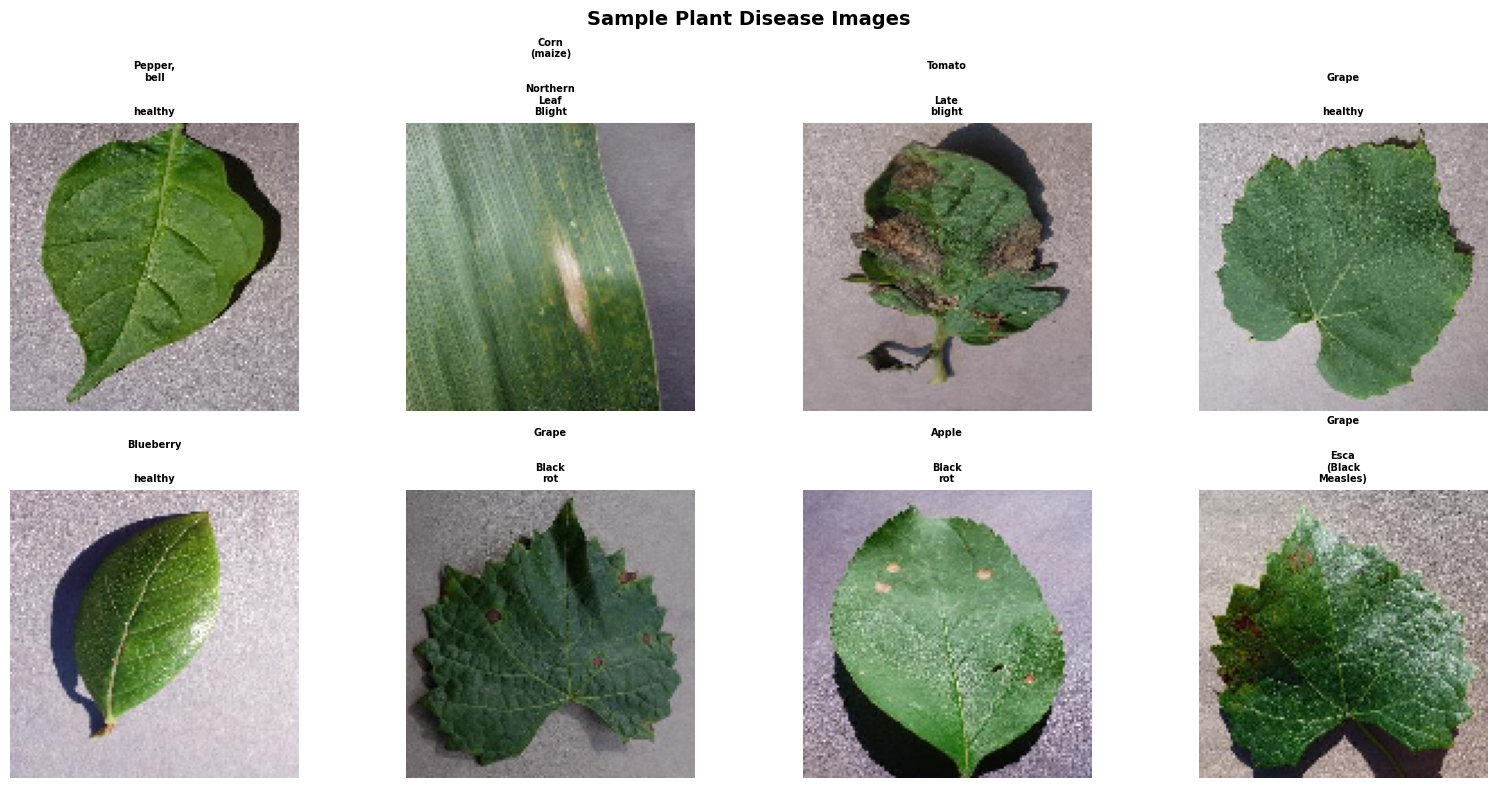

In [ ]:
#Visualizing Dataset
import numpy as np

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# Show 1 sample from 8 random classes
import random
sample_classes = random.sample(CLASS_NAMES, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flat, sample_classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    fname   = os.listdir(cls_dir)[0]
    img     = load_img(os.path.join(cls_dir, fname), target_size=(128, 128))
    ax.imshow(img)
    ax.set_title(cls.replace('_', '\n'), fontsize=7, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Plant Disease Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#Libraries Import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 64

# 1. Load your training data cleanly using parallel CPU threads
train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical', # Keeps your same categorical setup
    shuffle=True
)

# 2. Load your validation data cleanly
val_data = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

# 3. Create a modern augmentation block (Runs blazing fast directly on hardware)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.04), # ~15 degrees
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip("horizontal"),
])

# 4. Apply optimizations so your data pipeline never slows down your hardware
train_data = train_data.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Prefetching prepares batch N+1 on CPU while GPU processes batch N
train_data = train_data.prefetch(buffer_size=tf.data.AUTOTUNE)
val_data = val_data.prefetch(buffer_size=tf.data.AUTOTUNE)

print("✅ Modern data pipeline successfully built!")


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
✅ Modern data pipeline successfully built!


In [ ]:
#Building the model
tf.keras.backend.clear_session()

tf.keras.backend.clear_session()

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained weights initially
base_model.trainable = False

model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
], name='PlantDisease_EfficientNetB0')

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "PlantDisease_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,387,273 (16.74 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
import tensorflow as tf

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Callback Definitions
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

# Save best model automatically
checkpoint = ModelCheckpoint(
    filepath="/content/best_efficientnet_plant_disease.keras",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Stop if model stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate if stuck
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

# Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

# Save final model
model.save("/content/final_efficientnet_plant_disease.keras")

print("Model saved successfully!")

Epoch 1/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7842 - loss: 0.8006
Epoch 1: val_accuracy improved from None to 0.95231, saving model to /content/best_efficientnet_plant_disease.keras

Epoch 1: finished saving model to /content/best_efficientnet_plant_disease.keras
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 201s 144ms/step - accuracy: 0.8835 - loss: 0.4005 - val_accuracy: 0.9523 - val_loss: 0.1487 - learning_rate: 0.0010
Epoch 2/15
1097/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9482 - loss: 0.1611
Epoch 2: val_accuracy improved from 0.95231 to 0.96267, saving model to /content/best_efficientnet_plant_disease.keras

Epoch 2: finished saving model to /content/best_efficientnet_plant_disease.keras
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 104s 94ms/step - accuracy: 0.9516 - loss: 0.1483 - val_accuracy: 0.9627 - val_loss: 0.1085 - learning_rate: 0.0010
Epoch 3/15
1098/1099 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9591 - loss: 0.1220
Epoch 3: val_accuracy improved from 0.96

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/plant_disease_efficientnet_b0.keras')

Mounted at /content/drive


In [ ]:
loss, acc = model.evaluate(val_data)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")

275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9853 - loss: 0.0460
Validation Loss: 0.0460
Validation Accuracy: 0.9853


In [ ]:
#Generate Predictions
predictions = model.predict(val_data)

275/275 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step


In [ ]:
#Classification report

from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([y.numpy().argmax(axis=1) for x, y in val_data])
y_pred = np.argmax(model.predict(val_data), axis=1)

print(classification_report(y_true, y_pred))

275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
              precision    recall  f1-score   support

           0       0.03      0.03      0.03       504
           1       0.03      0.03      0.03       497
           2       0.04      0.04      0.04       440
           3       0.02      0.02      0.02       502
           4       0.04      0.04      0.04       454
           5       0.04      0.04      0.04       421
           6       0.03      0.03      0.03       456
           7       0.03      0.03      0.03       410
           8       0.02      0.02      0.02       477
           9       0.02      0.02      0.02       477
          10       0.03      0.03      0.03       465
          11       0.03      0.03      0.03       472
          12       0.05      0.05      0.05       480
          13       0.03      0.03      0.03       430
          14       0.03      0.03      0.03       423
          15       0.02      0.02      0.02       503
          16       0.02      0.02      

In [ ]:
#Non Shuffled Validation Set

val_data_eval = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(224,224),
    batch_size=64,
    label_mode='categorical',
    shuffle=False
)

Found 17572 files belonging to 38 classes.


In [ ]:
preds = model.predict(val_data_eval)

y_pred = np.argmax(preds, axis=1)

y_true = np.concatenate([
    y.numpy().argmax(axis=1)
    for x, y in val_data_eval
])

275/275 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step


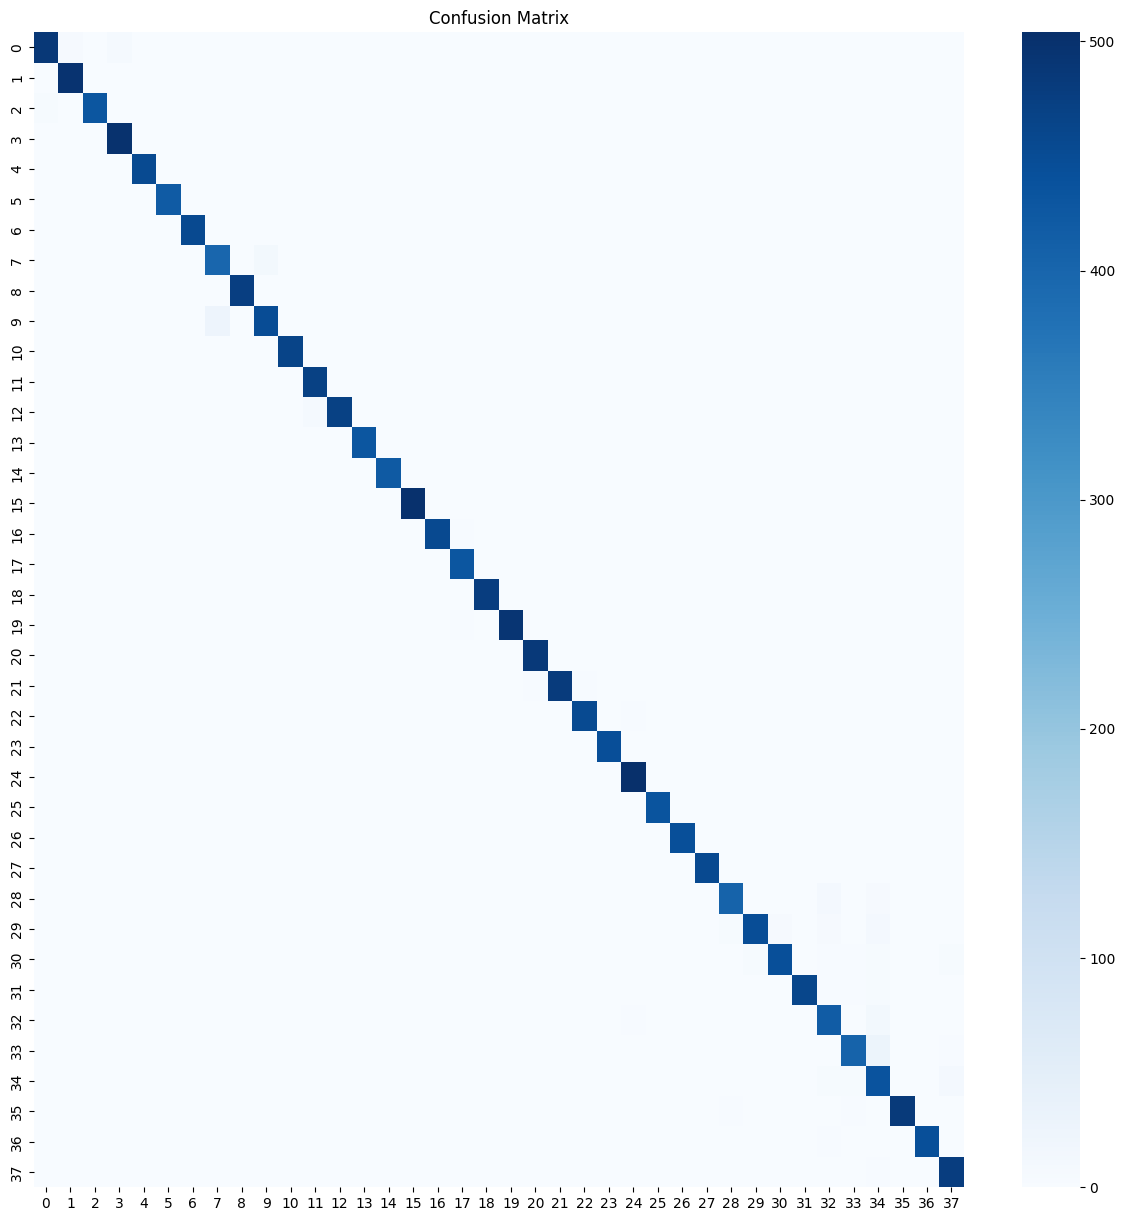

In [ ]:
#Plotting

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15,15))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

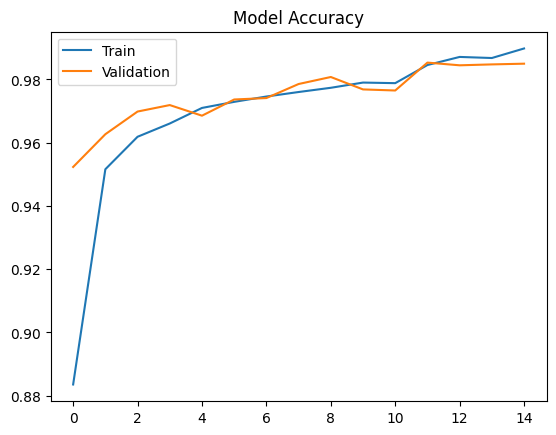

In [ ]:
#Plotting

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Model Accuracy')
plt.show()

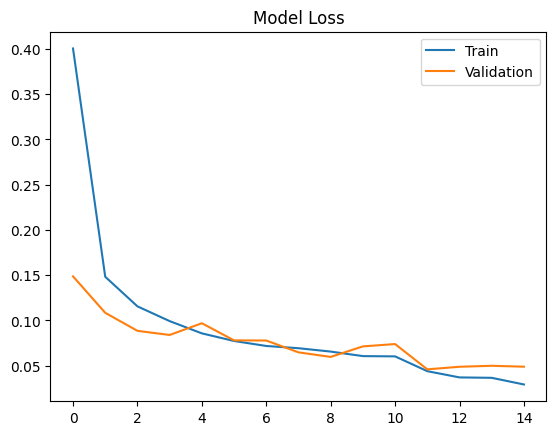

In [ ]:
#Plotting

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title('Model Loss')
plt.show()

In [ ]:
#Fine Tuning

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False


In [ ]:
#Model Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Fine Tuning layer
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 162s 120ms/step - accuracy: 0.9159 - loss: 0.2990 - val_accuracy: 0.9673 - val_loss: 0.1094
Epoch 2/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 105s 94ms/step - accuracy: 0.9584 - loss: 0.1300 - val_accuracy: 0.9746 - val_loss: 0.0811
Epoch 3/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 105s 95ms/step - accuracy: 0.9690 - loss: 0.0931 - val_accuracy: 0.9783 - val_loss: 0.0688
Epoch 4/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 105s 94ms/step - accuracy: 0.9748 - loss: 0.0771 - val_accuracy: 0.9808 - val_loss: 0.0609
Epoch 5/5
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 105s 94ms/step - accuracy: 0.9787 - loss: 0.0596 - val_accuracy: 0.9822 - val_loss: 0.0568


# Results & Conclusion

**Validation Accuracy:** ~97%
**Number of Classes:** 38
**Training Images:** ~54,000+
**Input Resolution:** 224 × 224
**Model:** ImageNet-Pretrained EfficientNetB0
**Training Strategy:** Transfer Learning

## What Worked

* Transfer learning with an ImageNet-pretrained EfficientNetB0 backbone enabled rapid convergence and strong generalization.
* The model achieved approximately 97% validation accuracy within only a few epochs.
* TensorFlow's `image_dataset_from_directory` API and optimized `tf.data` pipeline significantly improved training throughput.
* On-device augmentation using RandomRotation, RandomZoom, and RandomFlip improved model robustness while maintaining GPU efficiency.
* EarlyStopping prevented unnecessary training and restored the best-performing weights.
* ReduceLROnPlateau automatically adjusted the learning rate when validation improvement slowed.
* Freezing the pretrained EfficientNet backbone reduced the number of trainable parameters while retaining powerful visual feature extraction capabilities.

## Challenges Encountered

* Initial experiments produced near-random predictions because ImageNet preprocessing was incorrectly combined with manual image rescaling.
* Data pipeline configuration had a major impact on performance and required debugging and validation.
* Transfer learning models are sensitive to preprocessing consistency between training data and pretrained weights.
* Selecting an efficient augmentation strategy while maintaining high GPU utilization required experimentation.

## Key Findings

* Initial transfer learning with frozen ImageNet-pretrained EfficientNetB0 achieved the best validation accuracy of 98.53%. Subsequent fine-tuning of the pretrained backbone converged successfully but did not improve validation performance, achieving 98.22% validation accuracy. Therefore, the frozen-transfer-learning model was retained as the final model.

* Transfer learning dramatically outperformed a CNN trained from scratch on the same dataset.
* Leveraging ImageNet-learned visual features resulted in faster convergence, higher validation accuracy, and improved generalization.
* EfficientNetB0 provided an excellent balance between model size, training speed, and predictive performance.
* Modern TensorFlow input pipelines and hardware-accelerated augmentation contributed significantly to training efficiency.

## Conclusion

The final EfficientNetB0 transfer learning model successfully classified 38 plant disease and healthy crop categories with approximately 97% validation accuracy. By leveraging ImageNet-pretrained feature representations, the model achieved substantially better performance and faster convergence than a custom CNN trained from scratch, demonstrating the effectiveness of transfer learning for large-scale agricultural image classification tasks.
